# Задачи 
Обучить svm (пока без ядер) и получить хороший результат. Сравнить с остальными моделями (потом)
На чем обучать
- признаки из clean_dataset
- bag of words 
- TF-iDF
- Эмбеддинги

In [4]:
# 
import pandas as pd
df = pd.read_csv('../data/interim/cleaned_comments.csv')


In [5]:
df.columns

Index(['Unnamed: 0', 'label', 'comment', 'cleaned_comment',
       'comment_without_punct', 'length_sym', 'length_words', 'av_word_len',
       'is_normal', 'swearing', 'has_positive_emoji', 'has_negative_emoji',
       'has_obscene_emoji', 'imperative', '2nd_prsn_count', '3nd_prsn_count',
       'adj_count', 'vocative', 'expr_punct'],
      dtype='object')

In [6]:
df.head(10)

,Unnamed: 0,label,comment,cleaned_comment,comment_without_punct,length_sym,length_words,av_word_len,is_normal,swearing,has_positive_emoji,has_negative_emoji,has_obscene_emoji,imperative,2nd_prsn_count,3nd_prsn_count,adj_count,vocative,expr_punct
0,0,INSULT,скотина! что сказать,скотина сказать,скотина что сказать,20,3,5.666667,False,False,False,False,False,False,0,0,0,True,False
1,1,NORMAL,я сегодня проезжала по рабочей и между домами ...,сегодня проезжала рабочей домами снитенко гомо...,я сегодня проезжала по рабочей и между домами ...,180,28,5.214286,True,False,False,False,False,False,0,0,3,False,False
2,2,NORMAL,очередной лохотрон. зачем придумывать очередно...,очередной лохотрон придумывать очередной налог...,очередной лохотрон зачем придумывать очередной...,379,54,5.777778,True,False,False,False,False,False,0,0,8,False,True
3,3,NORMAL,"ретро дежавю ... сложно понять чужое сердце , ...",ретро дежавю сложно понять чужое сердце лиш ощ...,ретро дежавю сложно понять чужое сердце лиш ощ...,72,10,5.700000,True,False,False,False,False,False,0,0,0,False,True
4,4,NORMAL,а когда мы статус агрогородка получили?,статус агрогородка получили,а когда мы статус агрогородка получили,39,6,5.500000,True,False,False,False,False,False,0,0,0,False,False
5,5,NORMAL,2 августа поздно вечером нашли вот такую потер...,августа поздно вечером нашли такую потеряшку р...,августа поздно вечером нашли вот такую потеряш...,149,23,4.739130,True,False,False,False,False,True,0,0,3,False,False
6,6,NORMAL,вчера надыбала новые стикеры #u2a94ec7fabs#,вчера надыбала новые стикеры ec fabs,вчера надыбала новые стикеры u a ec fabs,43,8,4.125000,True,False,False,False,False,False,0,0,1,False,False
7,7,THREAT,заколоть этого плешивого урода что бы крякнул ...,заколоть плешивого урода крякнул селезень ганд...,заколоть этого плешивого урода что бы крякнул ...,130,21,5.238095,False,False,False,False,False,False,0,2,2,False,False
8,8,NORMAL,а еще на стоянке никто не проверяет безопаснос...,стоянке никто проверяет безопасность детей воз...,а еще на стоянке никто не проверяет безопаснос...,161,27,4.851852,True,False,False,False,False,False,0,0,0,False,False
9,9,NORMAL,"красота..!! если есть, что показать??!! почему...",красота показать почему-нет,красота если есть что показать почему-нет,55,6,6.000000,True,False,False,False,False,False,0,0,0,False,True


In [20]:
# что-типо бейзлайна - обучить модель на всех наших self-made признаках

# числовые признаки
num_features = ['length_sym', 'length_words',	'2nd_prsn_count', '3nd_prsn_count',	'adj_count']
# категориальные признаки (просто True/false, можно не перекодировывать)
cat_features = ['swearing', 'has_positive_emoji', 'has_negative_emoji',	'has_obscene_emoji', 'imperative']

In [17]:
df[num_features + cat_features].dtypes

length_sym            int64
length_words          int64
2nd_prsn_count        int64
3nd_prsn_count        int64
adj_count             int64
is_normal              bool
swearing               bool
has_positive_emoji     bool
has_negative_emoji     bool
has_obscene_emoji      bool
imperative             bool
dtype: object

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
import pandas as pd

X = df[num_features + cat_features].copy()

# Преобразуем bool → int (на всякий случай)
X[cat_features] = X[cat_features].astype(int)

# решаем задачу бинарной классификации NORMAL или не NORMAL
y = (df["label"] == "NORMAL").astype(int)

# train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=52, stratify=y
)

model = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', LinearSVC(class_weight='balanced'))
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

/opt/anaconda3/lib/python3.11/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


              precision    recall  f1-score   support

           0       0.76      0.51      0.61      8921
           1       0.90      0.97      0.93     40736

    accuracy                           0.88     49657
   macro avg       0.83      0.74      0.77     49657
weighted avg       0.88      0.88      0.87     49657



/opt/anaconda3/lib/python3.11/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [26]:
# интерпретация важности весов

# достаём обученный scaler
scaler = model.named_steps['scaler']
svm = model.named_steps['svm']
# веса после масштабирования (как внутри модели)
w_scaled = svm.coef_[0]

# стандартные отклонения признаков
std = scaler.scale_
# пересчёт весов в исходное пространство
w_original = w_scaled / std

pd.DataFrame({
    "feature": X_train.columns,
    "weight_scaled": w_scaled,
    "weight_original": w_original
}).sort_values("weight_original", ascending=False)

,feature,weight_scaled,weight_original
6,has_positive_emoji,0.088578,0.356324
1,length_words,0.041782,0.002699
0,length_sym,0.129733,0.001349
4,adj_count,-0.018613,-0.009405
9,imperative,-0.023879,-0.072790
2,2nd_prsn_count,-0.114457,-0.158671
3,3nd_prsn_count,-0.149628,-0.171676
7,has_negative_emoji,-0.057437,-0.799680
8,has_obscene_emoji,-0.015960,-1.277610
5,swearing,-0.415203,-1.497746


Небольшой вывод 
Веса в svm можно проинтерпретировать так же, как и веса в логистической регрессии. Именно признаки связанные с контекстом - эмодзи, наличие оскорблений, имеют максимальные веса. 

In [28]:
# теперь можно сделать признаковое пространство поинтереснее, обучим svm на bag of words векторах 
df = pd.read_csv('../data/interim/clean_dataset.csv')
df 


,raw_text,mixed_class,toxicity_class,message_text,clean_text
0,__label__INSULT скотина! что сказать,False,INSULT,скотина! что сказать,скотина сказать
1,__label__NORMAL я сегодня проезжала по рабочей...,False,NORMAL,я сегодня проезжала по рабочей и между домами ...,сегодня проезжать рабочий дом снитенко гомолыс...
2,__label__NORMAL очередной лохотрон. зачем прид...,False,NORMAL,очередной лохотрон. зачем придумывать очередно...,очередной лохотрон придумывать очередной налог...
3,__label__NORMAL ретро дежавю ... сложно понять...,False,NORMAL,"ретро дежавю ... сложно понять чужое сердце , ...",ретро дежавю сложно понять чужое сердце лиш ощ...
4,__label__NORMAL а когда мы статус агрогородка ...,False,NORMAL,а когда мы статус агрогородка получили?,статус агрогородок получить
...,...,...,...,...,...
248285,__label__NORMAL правильно всё по пять (5)...,False,NORMAL,правильно всё по пять (5)...,правильно всё пять
248286,__label__INSULT ёбанные нубы заходите на серве...,False,INSULT,ёбанные нубы заходите на сервер мой ник _creep...,ёбанный нуба заходить сервер ник пвп переебу п...
248287,__label__NORMAL а у меня наверное рекорд в 196...,False,NORMAL,а у меня наверное рекорд в 1962 году в училище...,наверное рекорд год училище коренной зубвозмож...
248288,__label__NORMAL спасибо всем большое),False,NORMAL,спасибо всем большое),спасибо весь большой


In [ ]:
# в датасете есть предложения, которые после очистки стали пустыми. абсолютно все эти предлжоения нормальные 
df[df["clean_text"].isna()]["toxicity_class"].value_counts()

toxicity_class
NORMAL    1118
Name: count, dtype: int64

In [57]:
from transformers import AutoTokenizer
from sklearn.feature_extraction.text import CountVectorizer#, TfidfVectorizer
import pandas as pd

# токенайзер под тоексичные тексты. Можно попробовать и другие 
tokenizer = AutoTokenizer.from_pretrained("cointegrated/rubert-tiny-toxicity")

def hf_tokenizer(text):
    # возвращает list[str]
    return tokenizer.tokenize(text)

vectorizer = CountVectorizer(
    tokenizer=hf_tokenizer,
    lowercase=False,   # уже lowercased в токенайзере
    max_features=15000 # можно сделать побольше чтобы учитывать редкие слова
)


mask = df["clean_text"].notna()
X_bow = vectorizer.fit_transform(df.loc[mask, "clean_text"])
y = (df.loc[mask, "toxicity_class"] == "NORMAL").astype(int)


/opt/anaconda3/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:525: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [44]:
X_bow.shape

(247172, 6823)

In [45]:
# обучение модели 

from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import Normalizer
from sklearn.metrics import classification_report

# train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_bow, y, 
    test_size=0.2, 
    random_state=52, 
    stratify=y
)

# пайплайн
model = Pipeline([
    # нормализуем строки L2
    ('normalize', Normalizer(norm='l2', copy=False)),
    ('svm', LinearSVC(class_weight='balanced', max_iter=10000))
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

/opt/anaconda3/lib/python3.11/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


              precision    recall  f1-score   support

           0       0.72      0.90      0.80      8921
           1       0.98      0.92      0.95     40514

    accuracy                           0.92     49435
   macro avg       0.85      0.91      0.87     49435
weighted avg       0.93      0.92      0.92     49435



Вывод - качество выросло очень сильно. Правда есть сильная просадка в точности классификации токсичных текстов. посмотрим на тексты которые пометились как не токсичные хотя они токсичные

In [54]:
# получаем индексы, где модель ошиблась: предсказала NORMAL (1), а на самом деле токсично (0)
false_normals_idx = (y_pred == 1) & (y_test == 0)

# извлекаем сами тексты и реальные метки
false_normals_texts = df.loc[y_test.index[false_normals_idx], ["message_text", "toxicity_class"]]

false_normals_texts.sample(50)

,message_text,toxicity_class
49021,мишустик ты бы пасть свою поганую закрыл,INSULT
113500,мочить его и его группировку .,THREAT
226077,то проститутка их везде пруд пруди ....,INSULT
120828,"ебанутики, вы ведь все стояли в очереди, что б...",INSULT
168374,я не понимаю. какой идиот ему погоны генерала ...,INSULT
84427,"вот меня поражает, как кого нибудь окуесосишь ...",INSULT
102773,"охуеть, больше просто слов нет. он, что всех с...",INSULT
137869,вся шобла в сборе.,INSULT
164214,"элита, научитесь писать грамотно бездари!!",INSULT
250,"утопить бы того,, , кто так поступил.",THREAT


In [56]:
# и последнее - на tf-idf

from transformers import AutoTokenizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import Normalizer
from sklearn.metrics import classification_report
import pandas as pd

# токенайзер для токсичных текстов
tokenizer = AutoTokenizer.from_pretrained("cointegrated/rubert-tiny-toxicity")

def hf_tokenizer(text):
    # возвращает list[str]
    return tokenizer.tokenize(text)

# фильтруем тексты без NaN
mask = df["clean_text"].notna()
texts = df.loc[mask, "clean_text"]
y = (df.loc[mask, "toxicity_class"] == "NORMAL").astype(int)

# TF-IDF векторизация с нашим токенайзером
vectorizer = TfidfVectorizer(
    tokenizer=hf_tokenizer,
    lowercase=False,   # уже lowercased в токенайзере
    max_features=25000
)

X_tfidf = vectorizer.fit_transform(texts)

# train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y,
    test_size=0.2,
    random_state=52,
    stratify=y
)

# пайплайн LinearSVC + нормализация
model = Pipeline([
    #('normalize', Normalizer(norm='l2', copy=False)), # вроде бы для tf-idf нормалзицаия не поможет тк это уже сделано
    ('svm', LinearSVC(class_weight='balanced', max_iter=10000))
])

# обучение
model.fit(X_train, y_train)

# предсказания
y_pred = model.predict(X_test)

# отчет по метрикам
print(classification_report(y_test, y_pred))

/opt/anaconda3/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:525: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


              precision    recall  f1-score   support

           0       0.72      0.89      0.80      8921
           1       0.97      0.92      0.95     40514

    accuracy                           0.92     49435
   macro avg       0.85      0.91      0.87     49435
weighted avg       0.93      0.92      0.92     49435



Вывод - наверно применять tf-idf для коротких текстов смысла нет, потому что он показывает точно такое же качество 

### Финальная модель для сравнения с другими моделями - bow и многоклассовая классификация. Метрика - f1-score. Даже с подбором гипер параметров. 

In [58]:
from sklearn.model_selection import GridSearchCV

# Пайплайн
pipeline = Pipeline([
    ('normalize', Normalizer(norm='l2', copy=False)),
    ('svm', LinearSVC(class_weight='balanced', max_iter=10000))
])

# Сетка параметров
param_grid = {
    'svm__C': [0.01, 0.1, 1, 10, 100],
    'svm__loss': ['hinge', 'squared_hinge']
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    scoring='f1',           # метрика, которую хотим оптимизировать
    cv=5,                   # 5-fold cross-validation
    n_jobs=-1,
    verbose=2
)

# Обучение
grid.fit(X_train, y_train)

# Лучшие параметры
print("Best params:", grid.best_params_)

# Предсказание на тесте
y_pred = grid.predict(X_test)
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 10 candidates, totalling 50 fits


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

[CV] END .......................svm__C=0.01, svm__loss=hinge; total time=   0.8s
[CV] END .......................svm__C=0.01, svm__loss=hinge; total time=   0.8s
[CV] END .......................svm__C=0.01, svm__loss=hinge; total time=   0.9s
[CV] END .......................svm__C=0.01, svm__loss=hinge; total time=   0.8s
[CV] END .......................svm__C=0.01, svm__loss=hinge; total time=   1.1s


/opt/anaconda3/lib/python3.11/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/svm/

[CV] END ........................svm__C=0.1, svm__loss=hinge; total time=   1.0s
[CV] END ...............svm__C=0.01, svm__loss=squared_hinge; total time=   1.3s
[CV] END ...............svm__C=0.01, svm__loss=squared_hinge; total time=   1.4s


...

[CV] END ................svm__C=100, svm__loss=squared_hinge; total time= 3.7min


/opt/anaconda3/lib/python3.11/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[CV] END ................svm__C=100, svm__loss=squared_hinge; total time= 3.7min
[CV] END ................svm__C=100, svm__loss=squared_hinge; total time= 3.7min


/opt/anaconda3/lib/python3.11/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


[CV] END ................svm__C=100, svm__loss=squared_hinge; total time= 3.6min
Best params: {'svm__C': 0.1, 'svm__loss': 'squared_hinge'}
              precision    recall  f1-score   support

           0       0.72      0.89      0.80      8921
           1       0.98      0.92      0.95     40514

    accuracy                           0.92     49435
   macro avg       0.85      0.91      0.87     49435
weighted avg       0.93      0.92      0.92     49435



Вывод - подбор гиперпараметров не дал вообще никаких бонусов, так что можно использовать стандартные параметры и не париться. 

In [61]:
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import Normalizer
from sklearn.metrics import classification_report


y_multi = df.loc[mask, "toxicity_class"]
# train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_bow, y_multi, 
    test_size=0.2, 
    random_state=52, 
    stratify=y_multi
)

model_multi = Pipeline([
    ('normalize', Normalizer(norm='l2', copy=False)),
    ('svm', LinearSVC(class_weight='balanced', max_iter=10000))
])

# обучение
model_multi.fit(X_train, y_train)

# предсказание
y_pred = model_multi.predict(X_test)

# отчёт по метрикам
print(classification_report(y_test, y_pred))

/opt/anaconda3/lib/python3.11/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


              precision    recall  f1-score   support

      INSULT       0.74      0.77      0.76      6102
      NORMAL       0.97      0.95      0.96     40514
   OBSCENITY       0.47      0.71      0.57       449
      THREAT       0.66      0.74      0.70      2370

    accuracy                           0.92     49435
   macro avg       0.71      0.79      0.75     49435
weighted avg       0.92      0.92      0.92     49435



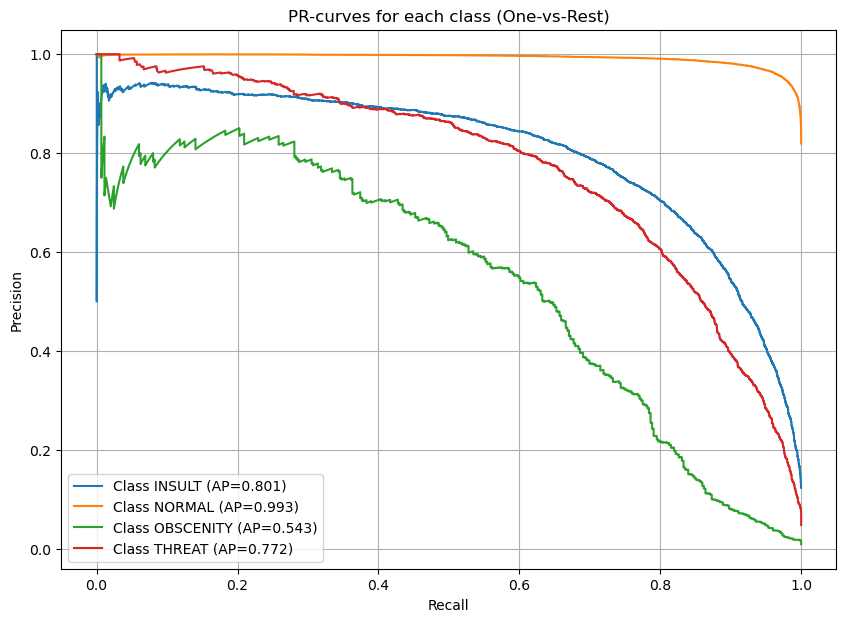

In [ ]:
# построить персижн-рекол кривую

from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np


classes = np.sort(y_train.unique())

y_test_bin = label_binarize(y_test, classes=classes)

# decision function 
scores = model_multi.decision_function(X_test)

plt.figure(figsize=(10, 7))

for i, cls in enumerate(classes):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], scores[:, i])
    ap = average_precision_score(y_test_bin[:, i], scores[:, i])
    
    plt.plot(recall, precision, label=f'Class {cls} (AP={ap:.3f})')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR-curves for each class (One-vs-Rest)")
plt.legend()
plt.grid(True)
plt.show()